In [ ]:
# @title Loading packages
!pip install lmfit
!pip install numdifftools
from lmfit import minimize, Parameters, Parameter, report_fit, Model

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pandas as pd
import csv
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.gridspec as gridspec


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 3.0 MB/s eta 0:00:00


In [ ]:
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker


In [ ]:
# @title 1. Setting parameters
# Molar masses
MW_s = 60.05        # g/mol (acetate)
MW_x = 24.6         # g/mol (biomass) values is derived from average elemental composition from Roels (1980) https://analyticalsciencejournals.onlinelibrary.wiley.com/doi/10.1002/bit.260221202
MW_Pi = 94.97       # g/mol (orthophosphate)
MW_3HB = 104.1      # g/mol (3HB)

# defined parameters (units)
params = {
'qs_max_g' : 7.832, # theoretical maximum acetate uptake rate before phosphate starvation (mol/mol biomass/hour)
'qs_max_p' : 0.6513, # theoretical maximum acetate uptake rate after phosphate starvation (mol/mol biomass/hour)
'Ks1' : 0.07937, # half saturation constant for qs_max_g (mol/L)
'Ks2' : 0.05469, # half saturation constant for qs_max_p (mol/L)
'Y_xs_g' : 0.1105, # theoretical maximum biomass:acetate before phosphate starvation (mol biomass/mol)
'Y_xs_p' : 0.2284, # theoretical maximum biomass:acetate after phosphate starvation (mol biomass/mol)
'qpi_max' : 0.009627, # theoretical maximum phopshate uptake rate (mol/mol biomass/hour)
'Kpi' : 8.621e-06, # half saturation constant for qpi_max (mol/L)
'qp_max' : 0.1335, # theoretical maximum PHB production rate (mol/mol biomass/hour)
'Pi_threshold' : 6.539e-06, # phopshate level where phosphate starvation is achieved (mol/L)
'n' : 1, # hill coefficient for phosphate-dependent PHB production
'Kp' : 0.07891, # half saturation constant for acetate-dependent PHB production (mol/L)
'm' : 3.004, # hill coefficient for phosphate-dependent PHB production
'Pi_min' : 1.6e-06, # offset value for phosphate level that assumed as background value (mol/L)
'cs_threshold' : 1e-06, # an arbitrary value that stop PHB production if acetate goes beyond this value during prediction (mol/L)
'cs_min' : 0.00017, # offset value for acetate level that assumed as background value (mol/L)
'Kxpi' : 0.002499, # half saturation constant for phosphate-biomass:acetate yield (mol/L)
'Ks_pi' : 1.555e-05, # half saturation constant for phosphate-biomass:acetate yield (mol/L)
  }

# setting x-axis (time) points for simulation (e.g. 200 points across 25 hours)
t_eval = np.linspace(0, 25, 200)

# number of steps allowed for the underlying solver when using the Levenberg-Marquardt method
mxstep = 500000000

In [ ]:
# @title 2. Define ODE function
def batch_ode(c, t, params):

    qs_g_max = params['qs_max_g']
    qs_p_max = params['qs_max_p']
    Ks1 = params['Ks1']
    Ks2 = params['Ks2']
    Yxs_g_max = params['Y_xs_g']
    Yxs_p_max = params['Y_xs_p']
    Pi_threshold = params['Pi_threshold']
    qp_max = params['qp_max']
    n = params['n']
    qpi_max = params['qpi_max']
    Kpi = params['Kpi']
    qp_max = params['qp_max']
    m = params['m']
    Pi_min = params['Pi_min']
    cs_min = params['cs_min']
    Kp = params['Kp']
    cs_threshold = params['cs_threshold']
    Kxpi = params['Kxpi']
    Ks_pi = params['Ks_pi']

    cs, cx, Pi, PHB = c

    # Effective Phosphate and acetate (adding offset for dataset)
    Pi = max(Pi - Pi_min, 0)
    cs = max(cs - cs_min, 0)

    # Pi-dependent binary switch for acetate uptake (growth phase -> production phase)
    Pi_avail = 0 if Pi < Pi_threshold else Pi / (1e-12 + Pi)

    # acetate uptake
    qs_g = qs_g_max * (cs / (Ks1 + cs)) * Pi_avail
    qs_p = qs_p_max * (cs / (Ks2 + cs)) * (1 - Pi_avail)
    qs = max(qs_g + qs_p, 0)

    # biomass growth
    Yxs = Yxs_g_max * (Pi / Kxpi + Pi) + Yxs_p_max
    mu = max(qs * Yxs, 0)

    # PHB production
    lim_Pi = Pi_threshold**n / (Pi_threshold**n + Pi**n) # sigmodal-dependency on Phosphate
    lim_cs = cs**m / (Kp**m + cs**m)  # sigmoidal-dependency on acetate
    qp = qp_max * lim_Pi * lim_cs

    # Pi uptake
    cs_avail = 0 if cs < cs_threshold else cs / (Ks_pi + cs)
    qpi = qpi_max * cs_avail * (Pi/ (Kpi + Pi))
    qpi = max(qpi, 0)

    # Differential equations
    d_cs = -qs * cx - qp * cx
    d_cx = mu * cx
    d_Pi = -qpi * cx
    d_PHB = qp * cx

    return [d_cs, d_cx, d_Pi, d_PHB]

In [ ]:
# @title Set initial conditions
# cs = acetate; cx = biomass; Pi = phosphate; PHB = PHB
# all variables are in mol/L

# high Pi group (1.32mM)
cs0_0 = 0.0590                   # mol/L
cx0_0 = 0.00303 / MW_x        # mol/L
Pi0_0 = 1.11 / 1000           # mol/L
PHB0_0 = 0.000407 / MW_3HB                   # mol/L

cs0_1 = 0.0726                  # mol/L
cx0_1 = 0.00229 / MW_x          # mol/L
Pi0_1 = 0.1036 / 1000           # mol/L
PHB0_1 = 0.000814 / MW_3HB                   # mol/L

# new attempt (0.0132mM Pi)
cs0_2 = 0.0654           # mol/L
cx0_2 = 0.00283 / MW_x          # mol/L
Pi0_2 = 0.0102 / 1000           # mol/L
PHB0_2 = 0.000745 / MW_3HB      # mol/L

# putting variable in a list
y0_0 = [cs0_0, cx0_0, Pi0_0, PHB0_0]
y0_1 = [cs0_1, cx0_1, Pi0_1, PHB0_1]
y0_2 = [cs0_2, cx0_2, Pi0_2, PHB0_2]

# concatenate every experimental group in a list
y0_list = [y0_0, y0_1, y0_2]


In [ ]:
# @title 3. Define Specific Residual Function
def multi_experiment_residual_specific(params, t_list, data_list, y0_list, sigma_list=None):
    combined_residuals = []
    for i in range(len(data_list)):
        t_current = t_list[i]
        data_current = data_list[i]
        y0_current = y0_list[i]
        sigma_current = sigma_list[i] if sigma_list is not None else 1.0

        temp_params = params.copy()

        model_output = odeint(batch_ode, y0_current, t_current, args=(temp_params,), mxstep=mxstep)
        res_current = (model_output - data_current) / sigma_current
        combined_residuals.append(res_current.ravel())

    return np.concatenate(combined_residuals)

In [ ]:
# @title 4. Data managing
# ID = 'ID'(as triplicate at the same timepoint in csv file)

# mean values
X_COL = 'time'      # time
Y1 = 'ace_mm'       # acetate
Y2 = 'pi_mm'        # (phosphate)
Y3 = 'biom_gl'      # (biomass)
Y4 = 'phb_gl'       # (PHB)

# standard deviation
Yerr1 = 'ace_sd'    # acetate
Yerr2 = 'pi_sd'     # phosphate
Yerr3 = 'biom_sd'   # biomass
Yerr4 = 'phb_sd'    # PHB

# uploading data csv
CSV_PATH0 = "/content/p0_mean_newpi_all_0.1SD_opt.csv"
CSV_PATH1 = "/content/p1_mean_all_0.1SD_opt.csv"
CSV_PATH2 = "/content/p2_mean_2nd_attempt_all_0.1SD_opt.csv"

# reading csv file
df0 = pd.read_csv(CSV_PATH0)
df1 = pd.read_csv(CSV_PATH1)
df2 = pd.read_csv(CSV_PATH2)

# Combine into (N, 4) matrix with corrected order: cs, cx, Pi, PHB and convert everything to mol/L
data_measured0 = np.column_stack((
    df0[Y1].to_numpy(dtype=float) / 1000,
    df0[Y3].to_numpy(dtype=float) / MW_x,
    df0[Y2].to_numpy(dtype=float) / 1000,
    df0[Y4].to_numpy(dtype=float) / MW_3HB
))

data_measured1 = np.column_stack((
    df1[Y1].to_numpy(dtype=float) / 1000,
    df1[Y3].to_numpy(dtype=float) / MW_x,
    df1[Y2].to_numpy(dtype=float) / 1000,
    df1[Y4].to_numpy(dtype=float) / MW_3HB
))

data_measured2 = np.column_stack((
    df2[Y1].to_numpy(dtype=float) / 1000,
    df2[Y3].to_numpy(dtype=float) / MW_x,
    df2[Y2].to_numpy(dtype=float) / 1000,
    df2[Y4].to_numpy(dtype=float) / MW_3HB
))

# Combine SD into (N, 4) matrix with corrected order: cs, cx, Pi, PHB and convert everything to mol/L
sigma_measured0 = np.column_stack((
    df0[Yerr1].to_numpy(dtype=float) / 1000,
    df0[Yerr3].to_numpy(dtype=float) / MW_x,
    df0[Yerr2].to_numpy(dtype=float) / 1000,
    df0[Yerr4].to_numpy(dtype=float) / MW_3HB
))

sigma_measured1 = np.column_stack((
    df1[Yerr1].to_numpy(dtype=float) / 1000,
    df1[Yerr3].to_numpy(dtype=float) / MW_x,
    df1[Yerr2].to_numpy(dtype=float) / 1000,
    df1[Yerr4].to_numpy(dtype=float) / MW_3HB
))

sigma_measured2 = np.column_stack((
    df2[Yerr1].to_numpy(dtype=float) / 1000,
    df2[Yerr3].to_numpy(dtype=float) / MW_x,
    df2[Yerr2].to_numpy(dtype=float) / 1000,
    df2[Yerr4].to_numpy(dtype=float) / MW_3HB
))

# 1. Organize Time vectors (List of 1D arrays)
t_list = [
    df0[X_COL].to_numpy(dtype=float),
    df1[X_COL].to_numpy(dtype=float),
    df2[X_COL].to_numpy(dtype=float)
]

# 2. Organize Observed Data (List of (N,4) arrays)
data_list = [
    data_measured0, # Shape (N1, 4)
    data_measured1, # Shape (N2, 4)
    data_measured2  # Shape (N3, 4)
]

# 3. Organize SD (List of (N,4) arrays)
sigma_list = [
    sigma_measured0,
    sigma_measured1,
    sigma_measured2
]

In [ ]:
# @title 5. Configure Parameters

# this is for plotting only so all constraints are relieved

fit_params = Parameters()

# Initialize from global params
for key, value in params.items():
    fit_params.add(key, value=value, vary=False, min = 0.0, max = 100)

In [ ]:
# @title 6. Optimization

result = minimize(
    multi_experiment_residual_specific,
    fit_params,
    args=(t_list, data_list, y0_list, sigma_list),
    nan_policy = 'omit',
    method='leastsq' # 'leastsq' is often faster/more robust for simple fitting
)
report_fit(result)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 0
    # data points      = 82
    # variables        = 0
    chi-square         = 320.660818
    reduced chi-square = 3.91049777
    Akaike info crit   = 111.820503
    Bayesian info crit = 111.820503
##  Warning: uncertainties could not be estimated:
[[Variables]]
    qs_max_g:      7.832 (fixed)
    qs_max_p:      0.6513 (fixed)
    Ks1:           0.07937 (fixed)
    Ks2:           0.05469 (fixed)
    Y_xs_g:        0.1105 (fixed)
    Y_xs_p:        0.2284 (fixed)
    Kpi:           8.621e-06 (fixed)
    qpi_max:       0.009627 (fixed)
    qp_max:        0.1335 (fixed)
    Pi_threshold:  6.539e-06 (fixed)
    n:             1 (fixed)
    Kp:            0.07891 (fixed)
    m:             3.004 (fixed)
    Pi_min:        1.6e-06 (fixed)
    cs_threshold:  1e-06 (fixed)
    cs_min:        0.00017 (fixed)
    Kxpi:          0.002499 (fixed)
    Ks_pi:         1.555e-05 (fixed)


Chi-square value: 320.6608
reduced Chi-square value: 3.9105
Note: parameter boundary is fixed


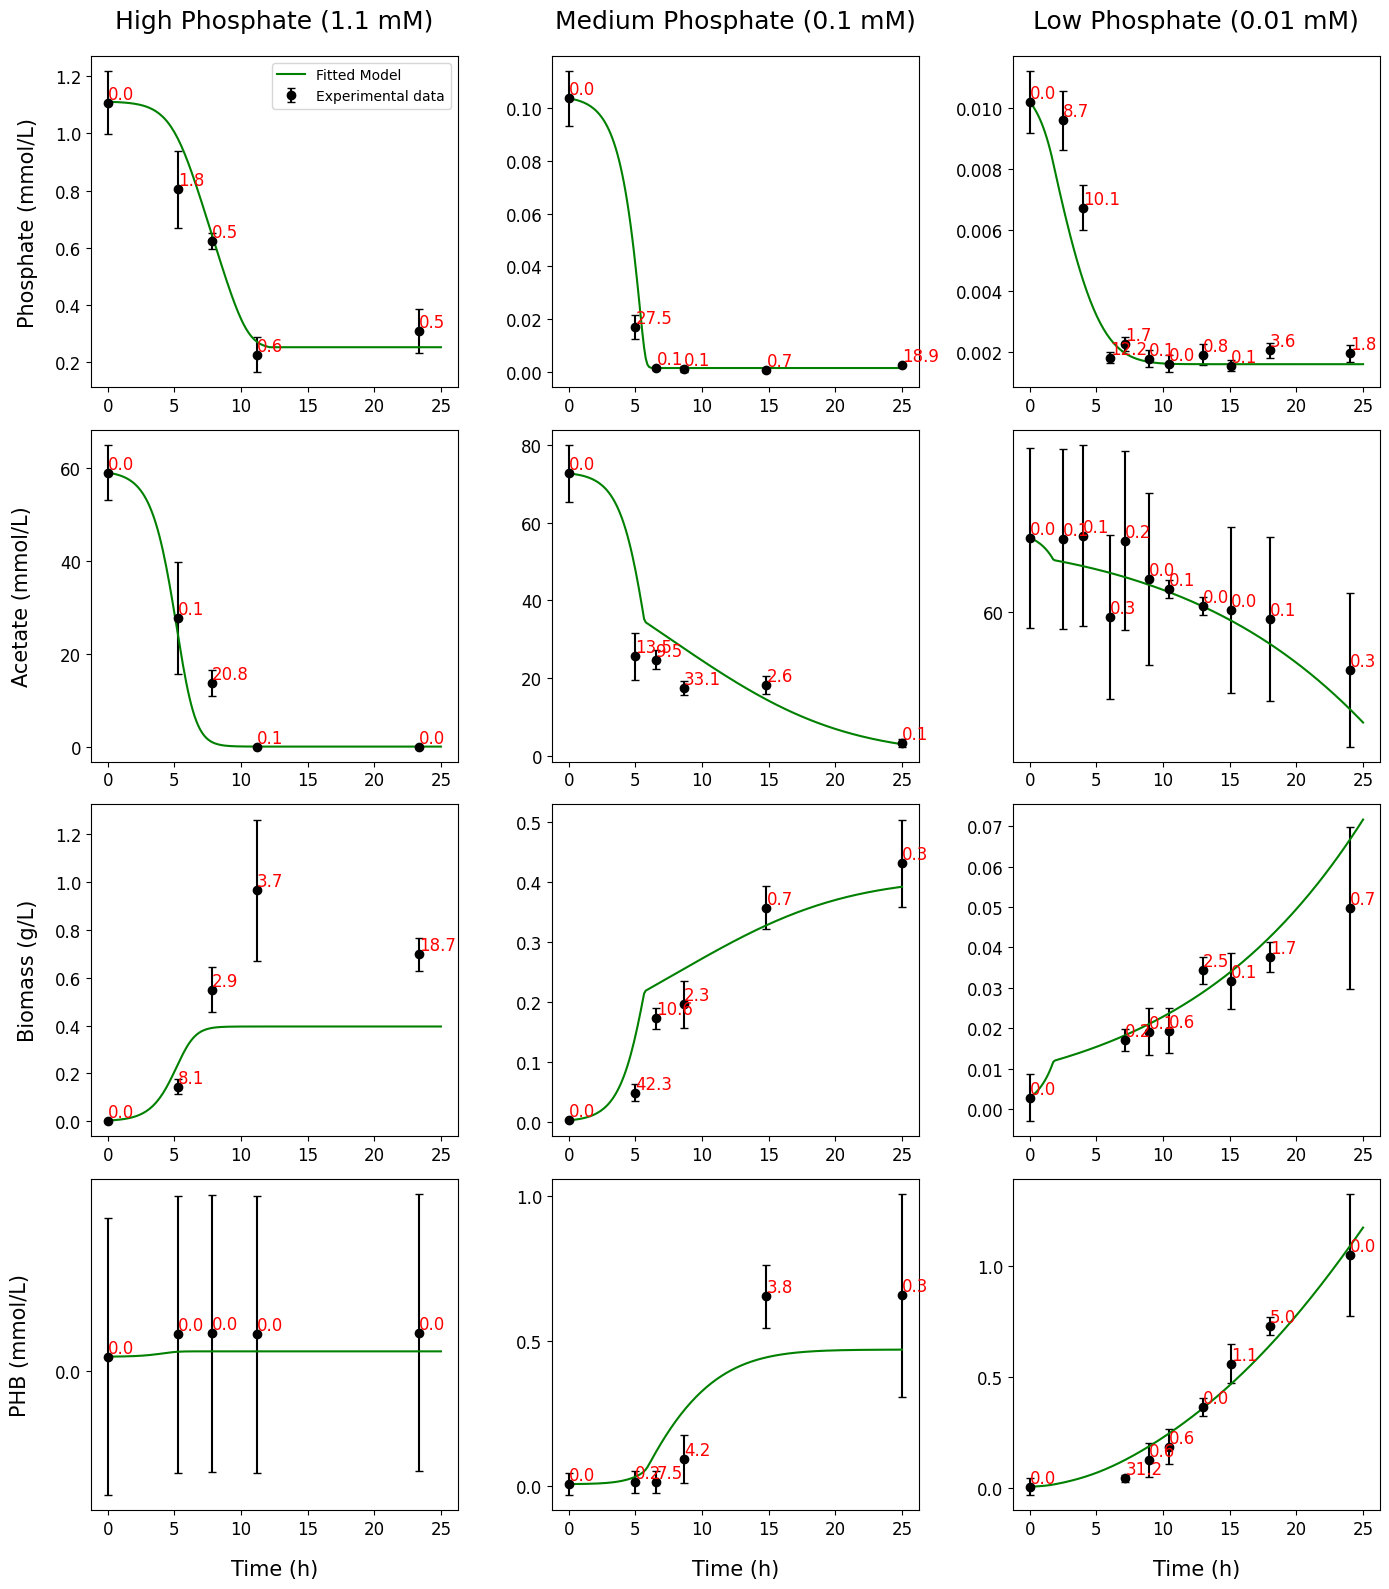

In [ ]:
# @title 7. Plotting result for preview (with chi-square value contributed at each point)
import matplotlib.ticker as ticker

# Generate plots for all 3 experiments
# Layout: 4 Rows (Metabolites) x 3 Columns (Experiments)
fig, axs = plt.subplots(4, 3, figsize=(14, 16))

# New variable names with updated units
var_names = ['Acetate (mmol/L)', 'Biomass (g/L)', 'Phosphate (mmol/L)', 'PHB (mmol/L)']

# Scaling factors (from M to new units)
# 0: Acetate (M -> mM), 1: Biomass (M -> g/L), 2: Pi (M -> mM), 3: PHB (M -> mM)
scaling_factors = {
    0: 1000,
    1: MW_x, # 24.6 g/mol
    2: 1000,
    3: 1000
}

# Custom Column Titles for Experiments
exp_titles = ["High Phosphate (1.1 mM)", "Medium Phosphate (0.1 mM)", "Low Phosphate (0.01 mM)"]

# Define the desired plotting order of variables (indices)
plot_order_indices = [2, 0, 1, 3]

# Custom Tick Intervals for Linear Plots (in NEW UNITS)
custom_ticks = {
    0: 20,    # Acetate: Every 20 mM
    3: 0.5    # PHB: Every 0.5 mM
}

subtitle_font_size = 18
axes_font_size = 15
tick_label_size = 12

# Use a smooth continuous time vector for plotting (0 to 25h)
t_eval1 = np.linspace(0, 25, 200)

# Custom Formatter for Log Plots (1e-2 style)
def log_tick_formatter(val, pos=None):
    return f"{val:.0e}".replace("e-00", "e-0").replace("e+00", "e+0")

for i in range(len(y0_list)):
    # Prepare parameters for this specific experiment
    sim_params = result.params.copy()

    # Simulate
    t_eval = t_list[i]
    y0 = y0_list[i]
    sim_data1 = odeint(batch_ode, y0, t_eval1, args=(sim_params,), mxstep=mxstep)
    sim_data = odeint(batch_ode, y0, t_eval, args=(sim_params,), mxstep=mxstep)

    # Plot for each row (k corresponds to the visual row index)
    for k, var_idx in enumerate(plot_order_indices):
        ax = axs[k, i] # Row: Visual Row k, Col: Experiment i

        # var_idx is the actual data index (0, 1, 2, or 3)
        scale = scaling_factors[var_idx]

        # Extract valid data (ignore NaNs) and SCALE
        valid_mask = ~np.isnan(data_list[i][:, var_idx])
        t_valid = t_eval[valid_mask]
        data_valid = data_list[i][valid_mask, var_idx] * scale
        sigma_valid = sigma_list[i][valid_mask, var_idx] * scale
        sim_valid = sim_data[valid_mask, var_idx] * scale

        # Measured datapoint (scatter)
        ax.errorbar(t_valid, data_valid, yerr=sigma_valid,
                    fmt='o', color='black', label='Experimental data', capsize=3)
        # Fitted curve (scaled)
        ax.plot(t_eval1, sim_data1[:, var_idx] * scale, color='green', label='Fitted Model')

        # # Apply custom y-limits if defined
        # if var_idx in custom_ylim:
        #     ax.set_ylim(custom_ylim[var_idx])

        # Apply Custom Ticks to Linear Plots
        if var_idx in custom_ticks:
            ax.yaxis.set_major_locator(ticker.MultipleLocator(custom_ticks[var_idx]))

        # Set titles and labels with custom font sizes and padding
        # Column headers (Experiments)
        if k == 0:
            ax.set_title(exp_titles[i], fontsize=subtitle_font_size, pad=20)

        # Row labels (Metabolites)
        if i == 0:
            # Add extra padding for Acetate (var_idx 0) to align with others
            pad = 20 if var_idx == 0 else 12
            if var_idx == 3: # PHB
                 pad = 18
            ax.set_ylabel(var_names[var_idx], fontsize=axes_font_size, labelpad=pad)

        # Bottom X-axis label
        if k == 3:
            ax.set_xlabel('Time (h)', fontsize=axes_font_size, labelpad=15)

        # Calculate and annotate Chi-square contributions
        chi2_contribs = ((sim_valid - data_valid) / sigma_valid)**2

        # Include chi2_contribs in zip so we can unpack 'c2'
        for tx, yx, c2 in zip(t_valid, data_valid, chi2_contribs):
            # Annotate with the Chi-square value
            ax.text(tx, yx, f'{c2:.1f}', fontsize=12, color='red',
                    va='bottom', ha='left')

        # Customize tick params
        ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

        if i == 0 and k == 0:
            ax.legend()

print(f"Chi-square value: {result.chisqr:.4f}")
print(f"reduced Chi-square value: {result.redchi:.4f}")

print("Note: parameter boundary is fixed")

plt.style.use('default')
plt.tight_layout()
plt.show()

In [ ]:
# @title 8. Simulating PHB titer and yield across Pi levels

# Range: ~0.0001 mM to ~1.32 mM (1e-7 M to 0.00132 M)
Pi_0_range = np.logspace(-6, np.log10(0.00132), 500)
Pi_0_mM = Pi_0_range * 1000

# Time vector
t_sim = np.linspace(0, 24, 200)          # 0 to 24 hours
base_y0 = y0_2                           # Use Experiment 1 initial conditions as template

titer_list = []
yield_list = []
rate_list = []
phb_percent_list = []
biomass_final_list = []
acetate_final_list = []

# Get parameters for simulation
sim_params = result.params

for Pi_0 in Pi_0_range:
    # Update initial condition
    y0_current = base_y0.copy()
    y0_current[2] = Pi_0 # Update Pi

    # Run simulation
    out = odeint(batch_ode, y0_current, t_sim, args=(sim_params,), mxstep=mxstep)

    # Extract values
    # indices: cs=0, cx=1, Pi=2, PHB=3
    cs_final = out[-1, 0]
    cs_initial = y0_current[0]
    cx_final = out[-1, 1]
    phb_final = out[-1, 3]
    phb_initial = y0_current[3]

    # Mass concentrations (g/L)
    mass_phb_final = phb_final
    mass_phb_initial = phb_initial
    mass_ace_final = cs_final
    mass_ace_initial = cs_initial
    mass_biomass_final = cx_final

    # Calculate Metrics
    # Titer (g/L)
    titer = mass_phb_final

    # Yield (g PHB / g Acetate consumed)
    ace_consumed = mass_ace_initial - mass_ace_final
    if ace_consumed > 1e-6:
        yld = (mass_phb_final - mass_phb_initial) / ace_consumed
    else:
        yld = 0.0

    # Rate (g/L/h)
    rate = titer / 24.0

    # %PHB (g PHB / (g Biomass + g PHB))
    total_dry_mass = mass_biomass_final + mass_phb_final
    if total_dry_mass > 0:
        phb_percent = (mass_phb_final / total_dry_mass) * 100
    else:
        phb_percent = 0.0

    # Append
    titer_list.append(titer)
    yield_list.append(yld)
    rate_list.append(rate)
    phb_percent_list.append(phb_percent)
    biomass_final_list.append(mass_biomass_final)
    acetate_final_list.append(mass_ace_final)

# Convert to numpy arrays
titer_arr = np.array(titer_list)
yield_arr = np.array(yield_list)
rate_arr = np.array(rate_list)
phb_percent_arr = np.array(phb_percent_list)
biomass_final_arr = np.array(biomass_final_list)
acetate_final_arr = np.array(acetate_final_list)

# Define metrics and their corresponding units based on the previous cell's context
# Note: The simulation used Molar units for mass_phb_final etc., so Titer is Molar.
metrics = {
    "Titer": (titer_arr*MW_3HB, "g PHB/L"),
    "Yield": (yield_arr*MW_3HB/MW_s, "g PHB/g Acetate"),
    "Productivity (Rate)": (rate_arr*MW_3HB, "g PHB/L/h"),
    "PHB Content": (phb_percent_arr*MW_3HB/MW_x, "% (g/g)")
}

print("Optimal Initial Phosphate Levels for Maximum Metrics:")
print("-" * 75)

for name, (data, unit) in metrics.items():
    # Find index of maximum value
    idx_max = np.argmax(data)

    # Get optimal Pi and the max value
    opt_pi = Pi_0_mM[idx_max]
    max_val = data[idx_max]

    print(f"{name:<20} : {opt_pi:.4f} mM  (Max Value: {max_val:.4g} {unit})")

Optimal Initial Phosphate Levels for Maximum Metrics:
---------------------------------------------------------------------------
Titer                : 0.0191 mM  (Max Value: 0.1785 g PHB/L)
Yield                : 0.0010 mM  (Max Value: 0.1986 g PHB/g Acetate)
Productivity (Rate)  : 0.0191 mM  (Max Value: 0.007438 g PHB/L/h)
PHB Content          : 0.0010 mM  (Max Value: 139.4 % (g/g))


In [ ]:
#@title 9. Predict PHB TRY based on Pi-levels
# Setting specific initial Phosphate concentration in mM
target_Pi_mM = 0.0191

# Convert to mol/L
target_Pi = target_Pi_mM / 1000.0

# Setup Simulation
t_sim_specific = np.linspace(0, 24, 200)  # 24 hours
y0_specific = y0_2.copy()                 # Use Experiment 2 initial conditions as base
y0_specific[2] = target_Pi                # Set specific Pi (Corrected index 2)

# Run Simulation
out_specific = odeint(batch_ode, y0_specific, t_sim_specific, args=(result.params,), mxstep=mxstep)

# Extract Final State
cs_final = out_specific[-1, 0]
cs_initial = y0_specific[0]
phb_final = out_specific[-1, 3]
phb_initial = y0_specific[3]
biomass_final = out_specific[-1, 1]

# --- Calculate Metrics (Molar units) ---
titer_M = phb_final
ace_consumed_M = cs_initial - cs_final
rate_M = titer_M / 24.0
if ace_consumed_M > 1e-9:
    yield_mol = (phb_final - phb_initial) / ace_consumed_M
else:
    yield_mol = 0.0
phb_percent_mol = (phb_final / (biomass_final + phb_final)) * 100

# --- Calculate Metrics (Mass units: g/L, g/g) ---
# Molecular weights: MW_3HB = 101.3 g/mol, MW_s (Acetate) = 60.05 g/mol, MW_x (Biomass) = 24.6 g/mol
titer_gL = titer_M * MW_3HB
rate_gL = titer_gL / 24.0

ace_consumed_g = ace_consumed_M * MW_s
phb_produced_g = (phb_final - phb_initial) * MW_3HB

if ace_consumed_g > 1e-9:
    yield_gg = phb_produced_g / ace_consumed_g
else:
    yield_gg = 0.0

# Biomass is typically measured as dry cell weight (DCW).
# If cx is mol/L, we convert to g/L using MW_x.
total_mass = (biomass_final * MW_x) + (phb_final * MW_3HB)
if total_mass > 0:
    phb_percent_mass = ((phb_final * MW_3HB) / total_mass) * 100
else:
    phb_percent_mass = 0.0

# Print Results
print(f"Results for Initial Phosphate = {target_Pi_mM} mM")
print("-" * 40)
print(f"{'Metric':<20} | {'Molar Value':<20} | {'Mass Value':<20}")
print("-" * 65)
print(f"{'Titer':<20} | {titer_M:.4e} M PHB/L    | {titer_gL:.4f} g PHB/L")
print(f"{'Rate':<20} | {rate_M:.4e} M/L/h      | {rate_gL:.4f} g/L/h")
print(f"{'Yield':<20} | {yield_mol:.4f} mol/mol     | {yield_gg:.4f} g/g")
print(f"{'PHB Content':<20} | {phb_percent_mol:.2f} % (mol/mol)   | {phb_percent_mass:.2f} % (g/g)")

Results for Initial Phosphate = 0.0248 mM
----------------------------------------
Metric               | Molar Value          | Mass Value          
-----------------------------------------------------------------
Titer                | 1.6628e-03 M PHB/L    | 0.1714 g PHB/L
Rate                 | 6.9283e-05 M/L/h      | 0.0071 g/L/h
Yield                | 0.0426 mol/mol     | 0.0732 g/g
PHB Content          | 16.18 % (mol/mol)   | 44.72 % (g/g)


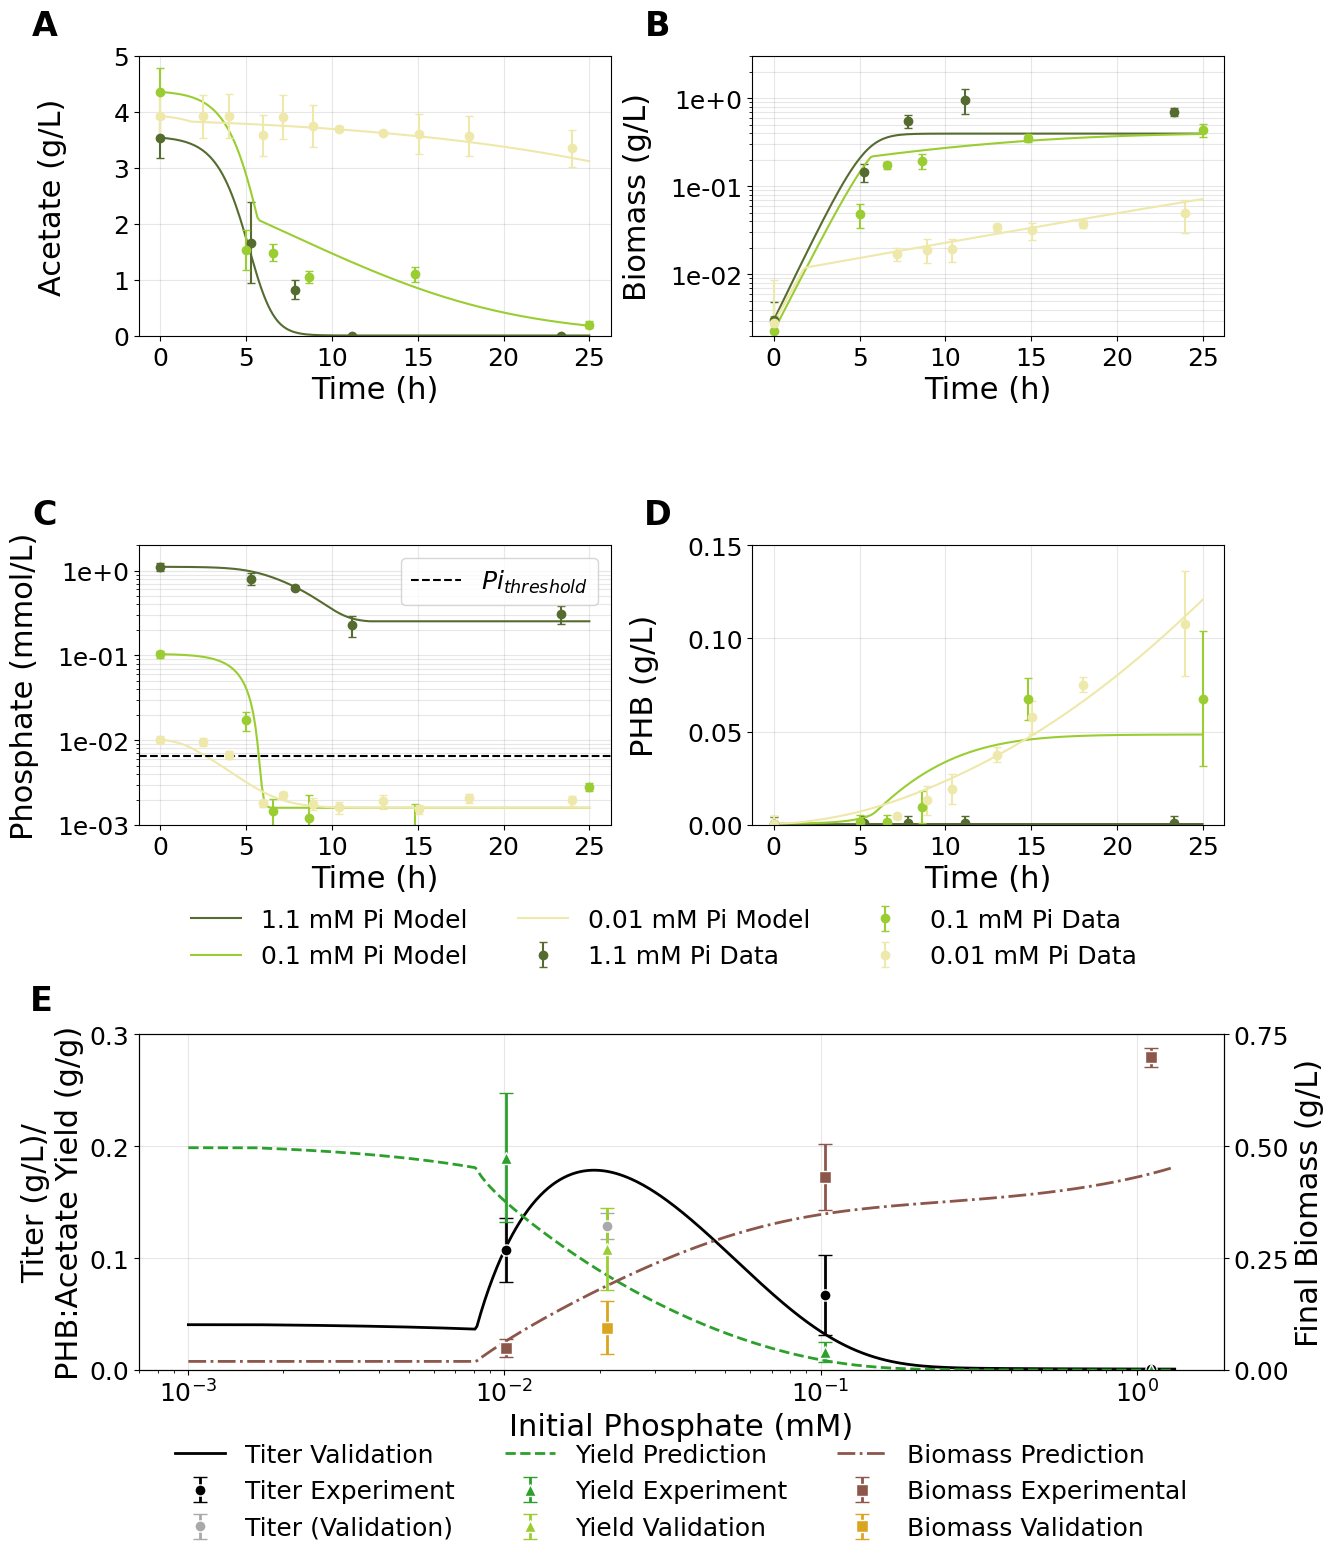

In [ ]:
# @title 10. Plotting Final Figures

# --- Font Customization ---
axis_label_fontsize = 22
tick_label_fontsize = 18
legend_fontsize = 18
subtitle_font_size= 24

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.7, wspace=0.3)

# # Convert Pi_0 to mM for plotting
Pi_0_mM = Pi_0_range * 1000

# time scale (25 hours)
t_eval_smooth = np.linspace(0, 25, 200)

# --- Top Section: Time-Course Dynamics (2x2) ---
# Variable names and scaling
var_names = ['Acetate (g/L)', 'Biomass (g/L)', 'Phosphate (mmol/L)', 'PHB (g/L)']
scaling_factors = {
    0: MW_s,        # Acetate M -> g/L
    1: MW_x,        # Biomass M -> g/L
    2: 1000,        # Pi M -> mM
    3: MW_3HB       # PHB M -> g/L
}

# Experimental Group Labels and Colors
exp_labels = ["1.1 mM Pi", "0.1 mM Pi", "0.01 mM Pi"]
colors = ['darkolivegreen', 'yellowgreen', 'palegoldenrod']
markers = ['o', 'o', 'o']

# Plot layout mapping: (row, col)
plot_mapping = {
    0: (0, 0), # Acetate
    1: (0, 1), # Biomass
    2: (1, 0), # Phosphate
    3: (1, 1)  # PHB
}

sublabels_top = ['A', 'B', 'C', 'D']

# Custom Y-axis limits
custom_ylim_top = {
    0: (0, 5),
    1: (0.002, 3),
    2: (0.001, 2),
    3: (0, 0.15)
}

# Custom Y-tick intervals
custom_ticks_top = {
    0: 1.0,
    1: 0.5,
    2: 0.2,
    3: 0.05
}

# Custom Y-label padding
custom_ypads_top = {
    0: 33,
    1: 13,
    2: 13,
    3: 20
}

# Custom X-position for sublabels
custom_sublabel_x_top = {
    0: -0.20,
    1: -0.20,
    2: -0.20,
    3: -0.20
}

################################ FONT SIZE #############################################
subtitle_font_size= 24

# Loop through variables for Top Section
axs_top = []
for var_idx in range(4):
    row, col = plot_mapping[var_idx]
    ax = fig.add_subplot(gs[row, col])
    axs_top.append(ax)

    scale = scaling_factors[var_idx]

    # Loop through experiments
    for i in range(len(y0_list)):
        # Simulation
        sim_params = result.params.copy()
        y0 = y0_list[i]
        sim_data_smooth = odeint(batch_ode, y0, t_eval_smooth, args=(sim_params,), mxstep=mxstep)

        # Experimental Data
        t_exp = t_list[i]
        data_exp = data_list[i][:, var_idx] * scale
        sigma_exp = sigma_list[i][:, var_idx] * scale

        valid_mask = ~np.isnan(data_exp)
        t_valid = t_exp[valid_mask]
        data_valid = data_exp[valid_mask]
        sigma_valid = sigma_exp[valid_mask]

        # Plot
        ax.plot(t_eval_smooth, sim_data_smooth[:, var_idx] * scale,
                color=colors[i], label=f"{exp_labels[i]} Model" if var_idx == 0 else "")
        ax.errorbar(t_valid, data_valid, yerr=sigma_valid,
                    fmt=markers[i], color=colors[i], capsize=3,
                    label=f"{exp_labels[i]} Data" if var_idx == 0 else "")

    # Formatting
    ax.set_xlabel('Time (h)', fontsize=axis_label_fontsize)
    ypad = custom_ypads_top.get(var_idx, 10)
    ax.set_ylabel(var_names[var_idx], fontsize=axis_label_fontsize, labelpad=ypad)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize)
    ax.grid(True, alpha=0.3, which="both")

    # Sublabel
    sublabel_x = custom_sublabel_x_top.get(var_idx, -0.25)
    ax.text(sublabel_x, 1.05, sublabels_top[var_idx], transform=ax.transAxes,
            fontsize=subtitle_font_size, fontweight='bold', va='bottom', ha='center')

    # Limits and Ticks
    if var_idx in custom_ylim_top:
        ax.set_ylim(custom_ylim_top[var_idx])
    if var_idx in custom_ticks_top:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(custom_ticks_top[var_idx]))

    # Pi Threshold Line
    if var_idx == 2:
        ax.axhline(result.params['Pi_threshold'].value * 1000, color='black', linestyle='--', label=r'$Pi_{threshold}$')
        ax.legend(loc='upper right', fontsize=legend_fontsize)

    # Log Scale
    if var_idx == 1 or var_idx == 2:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_tick_formatter))

# Legend for Top Section
handles, labels = axs_top[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.39), fontsize=legend_fontsize, framealpha=0.0, ncol=3)






csv_path = '/content/phb_pred.csv'

# --- Bottom Section: Metrics Analysis (Span Columns) ---
# 1. Read the CSV file
pi_col = 'pi_levels'
titer_col = 'phb_gl'
titer_sd_col = 'phb_std'
yield_col = 'yield_gg'
yield_sd_col = 'yield_std'
biom_col = 'final_biom_gl'
biom_sd_col = 'biom_std'

df = pd.read_csv(csv_path)

# Use correct column names from the loaded dataframe

exp_pi = df[pi_col].to_numpy(dtype=float)
exp_titer = df[titer_col].to_numpy(dtype=float)
exp_titer_sd = df[titer_sd_col].to_numpy(dtype=float)
exp_yield = df[yield_col].to_numpy(dtype=float)
exp_yield_sd = df[yield_sd_col].to_numpy(dtype=float)
exp_biom = df[biom_col].to_numpy(dtype=float)
exp_biom_sd = df[biom_sd_col].to_numpy(dtype=float)

# Create the bottom subplot spanning both columns
ax1 = fig.add_subplot(gs[2, :])

# Add subtitle 'E' to the bottom graph
ax1.text(-0.09, 1.05, 'E', transform=ax1.transAxes, fontsize=subtitle_font_size, fontweight='bold', va='bottom', ha='center')

# --- Left Axis: Titer (g/L) & Yield (g/g) ---
color_titer = 'black'
color_yield = 'tab:green'
color_highlight1 = 'darkgrey'  # Color for the 0.021 mM titer
color_highlight2 = 'goldenrod'  # Color for the 0.021 mM biomass
color_highlight3 = 'yellowgreen'  # Color for the 0.021 mM yield

ax1.set_xlabel('Initial Phosphate (mM)', fontsize=axis_label_fontsize)
ax1.set_ylabel('Titer (g/L)/\nPHB:Acetate Yield (g/g)', color='black', fontsize=axis_label_fontsize)

# Filter for the 0.021 mM data point
mask_021 = np.isclose(exp_pi, 0.021, atol=0.002)
mask_other = ~mask_021

# 1. Model Titer (g/L)
# titer_arr is Molar. g/L = M * MW_3HB
ln1 = ax1.plot(Pi_0_mM, titer_arr * MW_3HB, color=color_titer, label='Titer Validation', linewidth=2)

# 2. Experimental Titer (g/L)
# exp_titer is already g/L from the CSV loaded in previous step
sc1 = ax1.errorbar(exp_pi[mask_other], exp_titer[mask_other], yerr=exp_titer_sd[mask_other],
                    fmt='o', color=color_titer, ecolor=color_titer, elinewidth=2, capsize=5,
                    label='Titer Experiment', zorder=5, markeredgecolor='white', markersize=8)
sc1_021 = ax1.errorbar(exp_pi[mask_021], exp_titer[mask_021], yerr=exp_titer_sd[mask_021],
                    fmt='o', color=color_highlight1, ecolor=color_highlight1, elinewidth=2, capsize=5,
                    label='Titer (Validation)', zorder=6, markeredgecolor='white', markersize=8)

# 3. Model Yield (g/g)
# yield_arr is mol/mol. g/g = mol/mol * (MW_3HB / MW_s)
ln2 = ax1.plot(Pi_0_mM, yield_arr * (MW_3HB / MW_s), color=color_yield, linestyle='--', label='Yield Prediction', linewidth=2)

# 4. Experimental Yield (g/g)
# exp_yield is already g/g
sc2 = ax1.errorbar(exp_pi[mask_other], exp_yield[mask_other], yerr=exp_yield_sd[mask_other],
                    fmt='^', color=color_yield, ecolor=color_yield, elinewidth=2, capsize=5,
                    label='Yield Experiment', zorder=5, markeredgecolor='white', markersize=8)
sc2_021 = ax1.errorbar(exp_pi[mask_021], exp_yield[mask_021], yerr=exp_yield_sd[mask_021],
                    fmt='^', color=color_highlight3, ecolor=color_highlight3, elinewidth=2, capsize=5,
                    label='Yield Validation', zorder=6, markeredgecolor='white', markersize=8)

ax1.tick_params(axis='x', labelsize=tick_label_fontsize)
ax1.tick_params(axis='y', labelsize=tick_label_fontsize)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
ax1.set_ylim(0, 0.30) # Adjust to fit both Titer (~0.2) and Yield (~0.4)

# --- Right Axis: Biomass (g/L) ---
ax2 = ax1.twinx()
color_biomass = 'tab:brown'
ax2.set_ylabel('Final Biomass (g/L)', color='black', fontsize=axis_label_fontsize)

# 5. Model Biomass (g/L)
# biomass_final_arr is Molar. g/L = M * MW_x
ln3 = ax2.plot(Pi_0_mM, biomass_final_arr * MW_x, color=color_biomass, linestyle='-.', label='Biomass Prediction', linewidth=2)

# 6. Experimental Biomass (g/L)
sc3 = ax2.errorbar(exp_pi[mask_other], exp_biom[mask_other], yerr=exp_biom_sd[mask_other],
                    fmt='s', color=color_biomass, ecolor=color_biomass, elinewidth=2, capsize=5,
                    label='Biomass Experimental', zorder=5, markeredgecolor='white', markersize=8)
sc3_021 = ax2.errorbar(exp_pi[mask_021], exp_biom[mask_021], yerr=exp_biom_sd[mask_021],
                    fmt='s', color=color_highlight2, ecolor=color_highlight2, elinewidth=2, capsize=5,
                    label='Biomass Validation', zorder=6, markeredgecolor='white', markersize=8)

ax2.tick_params(axis='y', labelcolor='black', labelsize=tick_label_fontsize)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
ax2.set_ylim(0, 0.75)

# --- Combined Legend ---
lines = ln1 + [sc1, sc1_021] + ln2 + [sc2, sc2_021] + ln3 + [sc3, sc3_021]
labels = [l.get_label() for l in lines]

# Draw legend for bottom section
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=legend_fontsize, ncol=3, framealpha=0)

plt.subplots_adjust(bottom=0.15)
plt.savefig('my_plot.svg')

plt.show()

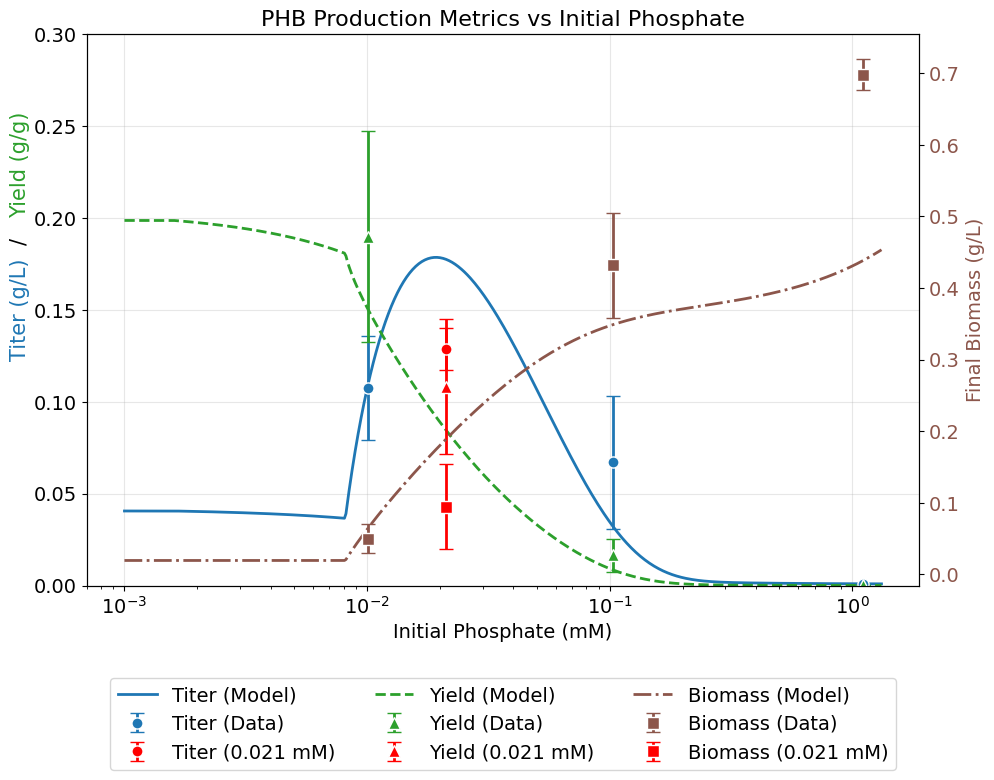

In [ ]:
# @title
fig, ax1 = plt.subplots(figsize=(10, 8))

# --- Font Customization ---
axis_label_fontsize = 14
tick_label_fontsize = 14
legend_fontsize = 14

# --- Left Axis: Titer (g/L) & Yield (g/g) ---
color_titer = 'tab:blue'
color_yield = 'tab:green'
color_highlight = 'red'  # Color for the 0.021 mM data point

# Filter for the 0.021 mM data point
mask_021 = np.isclose(exp_pi, 0.021, atol=0.002)
mask_other = ~mask_021

ax1.set_xlabel('Initial Phosphate (mM)', fontsize=axis_label_fontsize)
ax1.set_ylabel('', color='black', fontsize=axis_label_fontsize)

# 1. Model Titer (g/L)
# titer_arr is Molar. g/L = M * MW_3HB
ln1 = ax1.plot(Pi_0_mM, titer_arr * MW_3HB, color=color_titer, label='Titer (Model)', linewidth=2)

# 2. Experimental Titer (g/L)
# exp_titer is already g/L from the CSV loaded in previous step
sc1 = ax1.errorbar(exp_pi[mask_other], exp_titer[mask_other], yerr=exp_titer_sd[mask_other],
                    fmt='o', color=color_titer, ecolor=color_titer, elinewidth=2, capsize=5,
                    label='Titer (Data)', zorder=5, markeredgecolor='white', markersize=8)
sc1_021 = ax1.errorbar(exp_pi[mask_021], exp_titer[mask_021], yerr=exp_titer_sd[mask_021],
                    fmt='o', color=color_highlight, ecolor=color_highlight, elinewidth=2, capsize=5,
                    label='Titer (0.021 mM)', zorder=6, markeredgecolor='white', markersize=8)

# 3. Model Yield (g/g)
# yield_arr is mol/mol. g/g = mol/mol * (MW_3HB / MW_s)
ln2 = ax1.plot(Pi_0_mM, yield_arr * (MW_3HB / MW_s), color=color_yield, linestyle='--', label='Yield (Model)', linewidth=2)

# 4. Experimental Yield (g/g)
# exp_yield is already g/g
sc2 = ax1.errorbar(exp_pi[mask_other], exp_yield[mask_other], yerr=exp_yield_sd[mask_other],
                    fmt='^', color=color_yield, ecolor=color_yield, elinewidth=2, capsize=5,
                    label='Yield (Data)', zorder=5, markeredgecolor='white', markersize=8)
sc2_021 = ax1.errorbar(exp_pi[mask_021], exp_yield[mask_021], yerr=exp_yield_sd[mask_021],
                    fmt='^', color=color_highlight, ecolor=color_highlight, elinewidth=2, capsize=5,
                    label='Yield (0.021 mM)', zorder=6, markeredgecolor='white', markersize=8)

ax1.tick_params(axis='x', labelsize=tick_label_fontsize)
ax1.tick_params(axis='y', labelsize=tick_label_fontsize)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.3) # Adjust to fit both Titer (~0.2) and Yield (~0.4)

# --- Right Axis: Biomass (g/L) ---
ax2 = ax1.twinx()
color_biomass = 'tab:brown'
ax2.set_ylabel('Final Biomass (g/L)', color=color_biomass, fontsize=axis_label_fontsize)

# 5. Model Biomass (g/L)
# biomass_final_arr is Molar. g/L = M * MW_x
ln3 = ax2.plot(Pi_0_mM, biomass_final_arr * MW_x, color=color_biomass, linestyle='-.', label='Biomass (Model)', linewidth=2)

# 6. Experimental Biomass (g/L)
sc3 = ax2.errorbar(exp_pi[mask_other], exp_biom[mask_other], yerr=exp_biom_sd[mask_other],
                    fmt='s', color=color_biomass, ecolor=color_biomass, elinewidth=2, capsize=5,
                    label='Biomass (Data)', zorder=5, markeredgecolor='white', markersize=8)
sc3_021 = ax2.errorbar(exp_pi[mask_021], exp_biom[mask_021], yerr=exp_biom_sd[mask_021],
                    fmt='s', color=color_highlight, ecolor=color_highlight, elinewidth=2, capsize=5,
                    label='Biomass (0.021 mM)', zorder=6, markeredgecolor='white', markersize=8)

ax2.tick_params(axis='y', labelcolor=color_biomass, labelsize=tick_label_fontsize)

# --- Combined Legend ---
lines = ln1 + [sc1, sc1_021] + ln2 + [sc2, sc2_021] + ln3 + [sc3, sc3_021]
labels = [l.get_label() for l in lines]

# Draw legend
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=legend_fontsize, ncol=3)

# y-axis label
ybox3 = TextArea("Titer (g/L) ", textprops=dict(color=color_titer, size=15,rotation=90,ha='right',va='bottom'))
ybox2 = TextArea("/ ",     textprops=dict(color="0", size=15,rotation=90,ha='left',va='bottom'))
ybox1 = TextArea("Yield (g/g) ", textprops=dict(color=color_yield, size=15,rotation=90,ha='right',va='bottom'))

ybox = VPacker(children=[ybox1, ybox2, ybox3],align="bottom", pad=0, sep=5)

anchored_ybox = AnchoredOffsetbox(loc=8, child=ybox, pad=0., frameon=False, bbox_to_anchor=(-0.08, 0.4),
                                  bbox_transform=ax1.transAxes, borderpad=0.)

ax1.add_artist(anchored_ybox)

plt.title('PHB Production Metrics vs Initial Phosphate', fontsize=16)
plt.tight_layout()
plt.show()


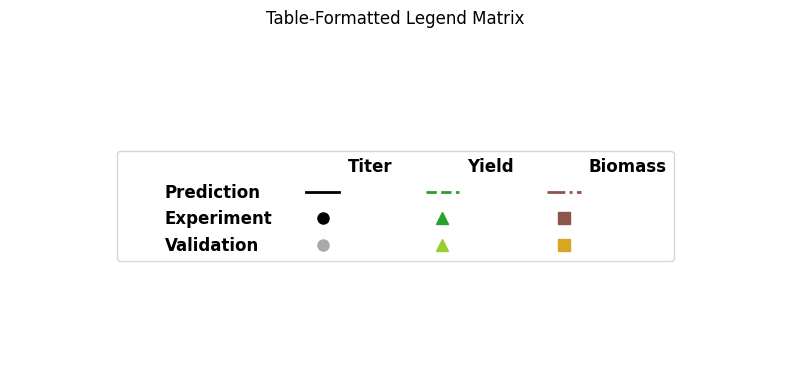

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a dummy figure
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')  # Hide axes for this demo

# Define colors
color_titer = 'black'
color_yield = 'tab:green'
color_biomass = 'tab:brown'

# 1. Create text proxies (invisible lines) for table headers
blank = Line2D([0], [0], color='none', label='')
col_pred = Line2D([0], [0], color='none', label='Prediction')
col_exp = Line2D([0], [0], color='none', label='Experiment')
col_val = Line2D([0], [0], color='none', label='Validation')

row_titer = Line2D([0], [0], color='none', label='Titer')
row_yield = Line2D([0], [0], color='none', label='Yield')
row_biomass = Line2D([0], [0], color='none', label='Biomass')

# 2. Create the actual handles for the legend (indicators)
titer_pred = Line2D([0], [0], color=color_titer, linestyle='-', linewidth=2, label='')
titer_exp = Line2D([0], [0], color=color_titer, marker='o', linestyle='none', markersize=8, label='')
titer_val = Line2D([0], [0], color='darkgrey', marker='o', linestyle='none', markersize=8, label='')

yield_pred = Line2D([0], [0], color=color_yield, linestyle='--', linewidth=2, label='')
yield_exp = Line2D([0], [0], color=color_yield, marker='^', linestyle='none', markersize=8, label='')
yield_val = Line2D([0], [0], color='yellowgreen', marker='^', linestyle='none', markersize=8, label='')

biomass_pred = Line2D([0], [0], color=color_biomass, linestyle='-.', linewidth=2, label='')
biomass_exp = Line2D([0], [0], color=color_biomass, marker='s', linestyle='none', markersize=8, label='')
biomass_val = Line2D([0], [0], color='goldenrod', marker='s', linestyle='none', markersize=8, label='')

# 3. Arrange handles and labels into a flat list corresponding to a 4-column grid
# Row 0: [BLANK, 'Prediction', 'Experiment', 'Validation']
# Row 1: ['Titer', Titer_Pred, Titer_Exp, Titer_Val]
# Row 2: ['Yield', Yield_Pred, Yield_Exp, Yield_Val]
# Row 3: ['Biomass', Biomass_Pred, Biomass_Exp, Biomass_Val]

handles = [
    blank, col_pred, col_exp, col_val,
    row_titer, titer_pred, titer_exp, titer_val,
    row_yield, yield_pred, yield_exp, yield_val,
    row_biomass, biomass_pred, biomass_exp, biomass_val
]

labels = [h.get_label() for h in handles]

# 4. Plot the legend
leg = ax.legend(handles, labels, ncol=4, loc='center',
                frameon=True, fontsize=12, handletextpad=0.5, columnspacing=2.0)

# Make the text proxies bold and aligned if needed (optional styling)
for text in leg.get_texts():
    if text.get_text() in ['Prediction', 'Experiment', 'Validation', 'Titer', 'Yield', 'Biomass']:
        text.set_fontweight('bold')

plt.title("Table-Formatted Legend Matrix")
plt.tight_layout()
plt.show()